In [1]:
!pip install -q kagglehub
#  install the newer official Kaggle client library — replaces the old
# kaggle.json + kaggle CLI workflow with a login() call, no file download needed

In [2]:
import kagglehub
kagglehub.login()
#  prompts you for your Kaggle USERNAME and API KEY directly in the notebook
# (no kaggle.json file required). Get these from kaggle.com → Settings → API section —
# even if the "download" doesn't trigger, the key is usually still visible/copyable there,
# or click "Create New Token" again and check if it shows the key on-screen instead of downloading it.

In [3]:
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")
# downloads (and caches) the dataset, returns the local folder path where it landed —
# no manual unzip needed, kagglehub handles that automatically
print(path)

100%|██████████| 262k/262k [00:00<00:00, 810kB/s]

Extracting files...
/root/.cache/kagglehub/datasets/rjmanoj/credit-card-customer-churn-prediction/versions/1


In [4]:
import pandas as pd

import os
df = pd.read_csv(os.path.join(path, "Churn_Modelling.csv"))
#  build the full file path from the returned folder + filename, then load it

In [5]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)
#  remove identifier columns that carry no predictive signal

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Exited"].value_counts()
# shows how many exited and how many are here ( let,s see if the data is baised to the leaving or staying customers)

,count
Exited,
0,7963
1,2037


In [10]:
print(df.columns.tolist())
df.head()

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [12]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [20]:
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
# commit: one-hot encode Geography and Gender, drop_first avoids dummy variable trap

df[['Geography_Germany','Geography_Spain','Gender_Male']] = df[['Geography_Germany','Geography_Spain','Gender_Male']].astype(int)
# commit: cast the new dummy columns from bool (True/False) to int (0/1).
# Newer pandas defaults get_dummies() output to bool dtype instead of the old
# 0/1 ints — this ensures downstream scaling and the Keras model get numeric
# input as expected, avoiding dtype issues.

KeyError: "None of [Index(['Geography', 'Gender'], dtype='object')] are in the [columns]"

In [21]:
print(df.columns.tolist())


['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [22]:
df[['Geography_Germany','Geography_Spain','Gender_Male']] = df[['Geography_Germany','Geography_Spain','Gender_Male']].astype(int)

In [23]:
df.head(4)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0


In [24]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [26]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [27]:
model = Sequential()
model.add(Dense(11, activation='sigmoid', input_dim=11))
model.add(Dense(11, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
history = model.fit(X_train_trf, y_train, batch_size=50, epochs=100, verbose=1, validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3820 - loss: 0.7887 - val_accuracy: 0.7969 - val_loss: 0.6163
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7958 - loss: 0.5504 - val_accuracy: 0.7969 - val_loss: 0.5102
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7958 - loss: 0.4946 - val_accuracy: 0.7969 - val_loss: 0.4847
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7958 - loss: 0.4786 - val_accuracy: 0.7969 - val_loss: 0.4742
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4691 - val_accuracy: 0.7969 - val_loss: 0.4659
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4606 - val_accuracy: 0.7969 - val_loss: 0.4581
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4524 - val_accuracy: 0.7969 - val_loss: 0.4509
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4451 - val_accu

In [31]:
y_pred = model.predict(X_test_trf)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [32]:
model.layers[1].get_weights()

[array([[-0.74283636,  0.96019346, -0.0840835 ,  0.1562721 ,  0.07197585,
         -0.81346303, -0.12072798, -0.41992906,  0.39376104, -0.8405998 ,
          0.6538618 ],
        [ 0.5705526 , -0.40960878, -0.7089572 ,  1.2953324 , -0.17383134,
         -0.5843241 ,  1.3584915 , -0.01230822,  0.5114656 , -1.2968214 ,
          0.73888737],
        [ 0.44526425, -1.0593104 , -0.08316939,  0.63768953, -0.02344563,
         -0.13222499, -0.34232348,  0.5329334 ,  0.28976113, -0.2584927 ,
         -0.5911053 ],
        [-0.6066175 ,  1.1219282 , -0.368278  ,  0.35862195, -0.4576851 ,
          0.25945455,  0.13081351, -0.0716184 , -0.12280089, -0.08532003,
          0.52514315],
        [ 0.06432417,  0.29721782, -0.03316317,  0.8171489 ,  0.2612286 ,
         -0.40082738,  1.0355948 ,  0.15592131,  0.7069545 , -0.5377807 ,
         -0.05920468],
        [ 1.1146313 , -0.7972679 ,  1.4113344 , -1.2868663 ,  0.09586187,
          0.9910956 , -1.6087414 ,  0.89608353, -1.5710273 ,  1.2343955

In [33]:
y_pred = (y_pred > 0.5).astype(int)

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.8585

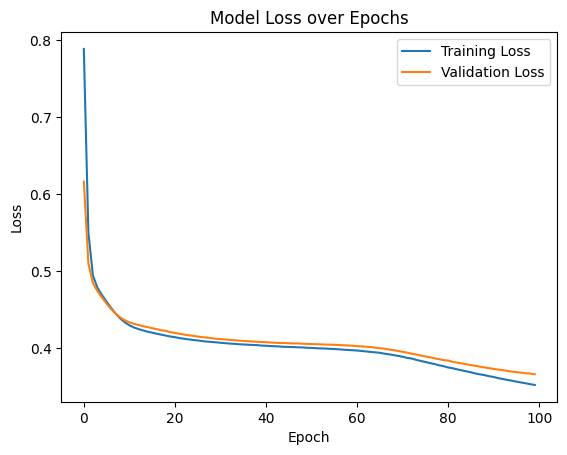

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
# commit: plot training loss, add label for legend

plt.plot(history.history['val_loss'], label='Validation Loss')
# commit: plot validation loss, add label for legend

plt.title('Model Loss over Epochs')
# commit: add chart title

plt.xlabel('Epoch')
# commit: label x-axis — training epoch number

plt.ylabel('Loss')
# commit: label y-axis — binary cross-entropy loss value

plt.legend()
# commit: show legend so blue/orange lines are identifiable

plt.show()
# commit: explicitly render the plot (avoids the "[<matplotlib.lines.Line2D...>]" text output above the chart)

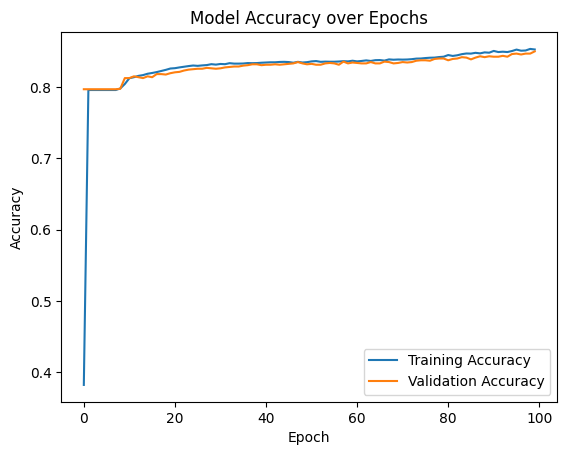

In [37]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()